In [58]:
!pip install torch matplotlib

  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [75]:
# loss function : sum of squares of loop equations
def loss(phi_pos, g, M, K):
    phi = torch.cat([-phi_pos, phi_pos])
    w = [torch.sum(phi**n) / M for n in range(0, K+3)]
    a2 = (np.sqrt(1 + 48*g) - 1) / (6*g) if g!= 0 else 4
    residuals = []
    for n in range(2, K+1, 2):
        Ln = w[n] +4 * g * w[n+2] - sum(w[k] * w[n-2-k] for k in range(0, n-1))
        rn = (1/a2)**n
        residuals.append(rn*Ln**2)
    return sum(residuals)


# gradient descent over the eigenvalues of the master field
def run_rma(M, K, g, lr=0.02, num_epochs=1000):
    print(f"Starting gradient descent: M={M}, K={K}, g={g}, lr={lr}, epochs={num_epochs}")
    
    phi_pos = torch.rand(M//2).double()
    phi_pos.requires_grad_(True)
    optim = torch.optim.Adam([phi_pos], lr=lr)
    
    for epoch in range(num_epochs):
        optim.zero_grad()
        L = loss(phi_pos, g, M, K)
        L.backward()
        optim.step()
        if epoch % 200 == 0:
            print(f"  epoch {epoch}/{num_epochs}, loss {L.item():.6e}")
            
    with torch.no_grad():
        phi = torch.cat([-phi_pos, phi_pos])
        w = [torch.sum(phi**n) / M for n in range(0, K+3)]

    print(f"Done. Final loss: {L.item():.6e}\n")
    return w, phi,L.item() #return the moments, the master field and the loss

from math import comb,factorial
import numpy as np

def moments_exact(g, n_max):
    if g == 0:
        return [comb(2*n, n) / (n+1) for n in range(n_max+1)]
    a2 = (np.sqrt(1 + 48*g) - 1) / (6*g)
    moments = []
    for n in range(n_max+1):
        coeff = factorial(2*n) / (factorial(n) * factorial(n+2))
        w = coeff * (a2/4)**n * (2*(n+1) - n*a2/4)
        moments.append(w)
    return moments

Starting gradient descent: M=50, K=15, g=1, lr=0.02, epochs=1000
  epoch 0/1000, loss 1.001947e+02
  epoch 200/1000, loss 1.986910e-02
  epoch 400/1000, loss 4.821123e-04
  epoch 600/1000, loss 2.214675e-04
  epoch 800/1000, loss 1.505550e-04
Done. Final loss: 1.018738e-04



IndexError: list index out of range

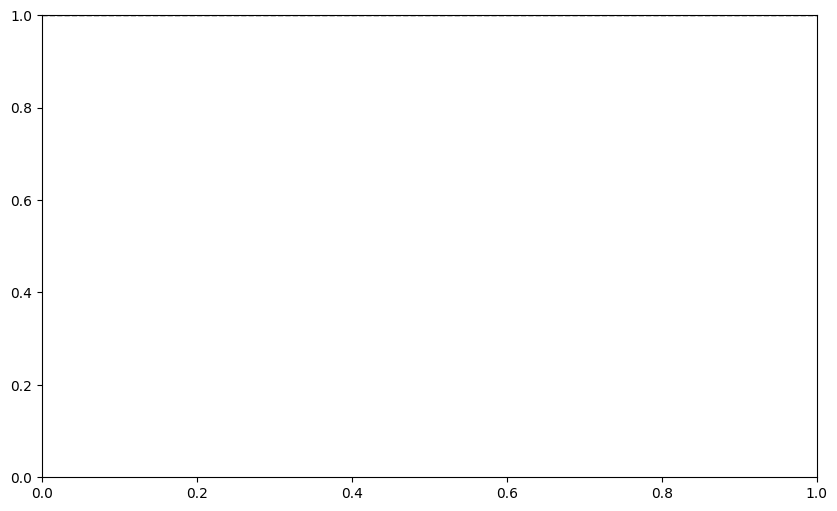

In [72]:
M_values = [50,100,150,200]
g=1


k_max = min(M_values)//2
ks = np.array(range(0, k_max+1))
w_exact = np.array(moments_exact(g, k_max))

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(1.0, color='k', lw=1, linestyle='--', label='exact')

for M in M_values:
    K = int(M*0.3//1)
    w, _,loss_val = run_rma(M, K, g)
    w_num = np.array([w[2*k].item() for k in ks])
    ax.plot(ks, w_num / w_exact, '-o', markersize=3, label=f'M={M}, loss={loss_val:.1e}')

ax.set_xlabel('k')
ax.set_ylabel('$w_{2k} / w_{2k}^\\mathrm{exact}$')
ax.set_title(f'Normalized moments, g={g}')
ax.legend()
plt.tight_layout()
plt.show()

In [76]:
M=50
K=100
g=0

w, phi,_ = run_rma(M, K, g)

Starting gradient descent: M=50, K=100, g=0, lr=0.02, epochs=1000
  epoch 0/1000, loss 3.883488e-02
  epoch 200/1000, loss 1.619788e-05
  epoch 400/1000, loss 3.019690e-06
  epoch 600/1000, loss 2.649438e-06
  epoch 800/1000, loss 2.622070e-06
Done. Final loss: 2.601875e-06



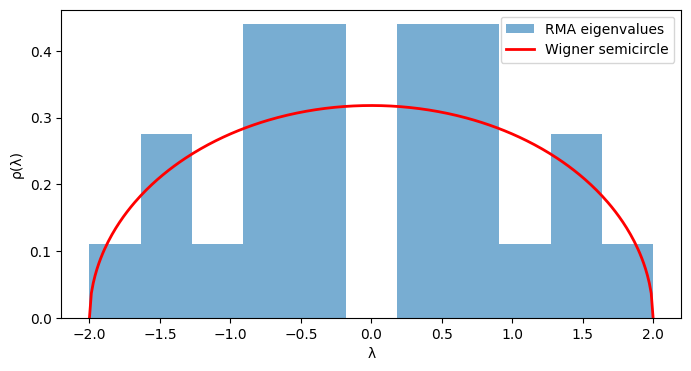

In [80]:
phi_vals = np.sort(phi.detach().numpy())
lam = np.linspace(-2, 2, 300)
rho_exact = np.sqrt(np.maximum(4 - lam**2, 0)) / (2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(phi_vals, bins=np.linspace(-2, 2, 12), 
        density=True, alpha=0.6, label='RMA eigenvalues')
ax.plot(lam, rho_exact, 'r-', lw=2, label='Wigner semicircle')
ax.set_xlabel('λ')
ax.set_ylabel('ρ(λ)')
ax.legend()
plt.show()

In [71]:
print([w[2*k] for k in range(0,10)])
print(moments_exact(0,10))

[tensor(1., dtype=torch.float64), tensor(0.5981, dtype=torch.float64), tensor(0.6076, dtype=torch.float64), tensor(0.7119, dtype=torch.float64), tensor(0.8885, dtype=torch.float64), tensor(1.1494, dtype=torch.float64), tensor(1.5221, dtype=torch.float64), tensor(2.0496, dtype=torch.float64), tensor(2.7955, dtype=torch.float64), tensor(3.8520, dtype=torch.float64)]
[1.0, 1.0, 2.0, 5.0, 14.0, 42.0, 132.0, 429.0, 1430.0, 4862.0, 16796.0]
